# FASE 4: Feature Engineering basado en evidencia del EDA

Contexto empirico previo:
- Autocorrelacion negativa fuerte en lag 1 (mean reversion)
- Lags posteriores debiles/inestables
- Retornos con heavy tails (kurtosis alta)
- Volatilidad no constante

Decision metodologica para esta fase:
- Usar solo Dataset A (sin imputacion)
- Construir features minimas y justificadas
- Evaluar aporte de cada feature sin entrenar modelos

In [1]:
# 0) Librerias
import importlib
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

if importlib.util.find_spec('sklearn') is None:
    print('Instalando scikit-learn...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-learn'])

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.feature_selection import mutual_info_regression

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid')

c:\Users\leynd\OneDrive\Escritorio\Tesis\implementaciones\desarrollov2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga de datos y construccion del dataset base (A)
Se usa la serie de trading days y se construye retorno logaritmico diario por emisor.
El target sera retorno en t+1 para evaluar relevancia de features en t.

In [2]:
dataset_name = 'beta3/Historical_Data_of_Ecuador_Stock_Exchange'
dataset = load_dataset(dataset_name, 'default_stocks')
df = dataset['stocks'].to_pandas()

empresas_objetivo = ['CORPORACION FAVORITA C.A.', 'BANCO GUAYAQUIL S.A.']
emisor_col = 'EMISOR'
fecha_col = 'FECHA NEGOCIACIÓN'
precio_col = 'PRECIO'

df = df[df[emisor_col].isin(empresas_objetivo)].copy()
df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce')
df[precio_col] = pd.to_numeric(df[precio_col], errors='coerce')
df = df.dropna(subset=[fecha_col, precio_col]).copy()
df = df.sort_values([emisor_col, fecha_col]).reset_index(drop=True)

series_a = []
for empresa in empresas_objetivo:
    g = df[df[emisor_col] == empresa].copy()

    # Precio representativo del dia: ultimo trade del dia
    diario = (
        g.sort_values(fecha_col)
        .groupby(fecha_col, as_index=True)[precio_col]
        .last()
        .to_frame('precio_trade_day')
    )

    diario['ret'] = np.log(diario['precio_trade_day'] / diario['precio_trade_day'].shift(1))
    diario['empresa'] = empresa
    diario = diario.reset_index().rename(columns={fecha_col: 'fecha'})
    series_a.append(diario)

df_a = pd.concat(series_a, ignore_index=True)
df_a = df_a.sort_values(['empresa', 'fecha']).reset_index(drop=True)

print('Shape dataset A (con retornos):', df_a.shape)
display(df_a.head())

Shape dataset A (con retornos): (2847, 4)


,fecha,precio_trade_day,ret,empresa
0,2019-01-02,0.96,NaN,BANCO GUAYAQUIL S.A.
1,2019-01-03,0.96,0.000000,BANCO GUAYAQUIL S.A.
2,2019-01-14,0.96,0.000000,BANCO GUAYAQUIL S.A.
3,2019-01-15,0.96,0.000000,BANCO GUAYAQUIL S.A.
4,2019-01-16,0.94,-0.021053,BANCO GUAYAQUIL S.A.


## 2. Construccion de features minimas obligatorias
Features:
- lag_1 (critico)
- lag_2 a lag_5
- rolling mean (3, 5)
- rolling std (3, 5)

Target:
- target_ret_t1: retorno de t+1

In [3]:
feature_rows = []

for empresa in empresas_objetivo:
    d = df_a[df_a['empresa'] == empresa].copy().sort_values('fecha')

    # Lags de retornos
    for lag in [1, 2, 3, 4, 5]:
        d['lag_{}'.format(lag)] = d['ret'].shift(lag)

    # Rolling features cortas (coherentes con evidencia de corto plazo)
    d['roll_mean_3'] = d['ret'].rolling(3).mean()
    d['roll_mean_5'] = d['ret'].rolling(5).mean()
    d['roll_std_3'] = d['ret'].rolling(3).std()
    d['roll_std_5'] = d['ret'].rolling(5).std()

    # Target en horizonte 1 paso
    d['target_ret_t1'] = d['ret'].shift(-1)

    feature_rows.append(d)

df_feat = pd.concat(feature_rows, ignore_index=True)

feature_cols = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'roll_mean_3', 'roll_mean_5', 'roll_std_3', 'roll_std_5']

# Se remueven NaN solo por construccion temporal de lags/rolling/target
df_model_base = df_feat.dropna(subset=feature_cols + ['target_ret_t1']).copy()

print('Shape con features + target (sin NaN estructural):', df_model_base.shape)
display(df_model_base[['fecha', 'empresa', 'ret'] + feature_cols + ['target_ret_t1']].head())

Shape con features + target (sin NaN estructural): (2833, 14)


,fecha,empresa,ret,lag_1,lag_2,lag_3,lag_4,lag_5,roll_mean_3,roll_mean_5,roll_std_3,roll_std_5,target_ret_t1
6,2019-01-14,CORPORACION FAVORITA C.A.,0.011976,0.020285,-0.004090,0.004090,-0.008163,0.008163,0.009390,0.004820,0.012391,0.011607,0.000000
7,2019-01-15,CORPORACION FAVORITA C.A.,0.000000,0.011976,0.020285,-0.004090,0.004090,-0.008163,0.010754,0.006452,0.010197,0.009749,0.003960
8,2019-01-16,CORPORACION FAVORITA C.A.,0.003960,0.000000,0.011976,0.020285,-0.004090,0.004090,0.005312,0.006426,0.006101,0.009757,0.027292
9,2019-01-17,CORPORACION FAVORITA C.A.,0.027292,0.003960,0.000000,0.011976,0.020285,-0.004090,0.010418,0.012703,0.014747,0.011277,-0.007722
10,2019-01-18,CORPORACION FAVORITA C.A.,-0.007722,0.027292,0.003960,0.000000,0.011976,0.020285,0.007843,0.007101,0.017827,0.013337,0.026770


## 3. Tratamiento de outliers y escalado (sin eliminar datos)
No se eliminan outliers de forma arbitraria.
Se reporta su magnitud y se compara StandardScaler vs RobustScaler.

In [4]:
# Diagnostico de colas/outliers en retorno
out_rows = []
for empresa in empresas_objetivo:
    s = df_model_base[df_model_base['empresa'] == empresa]['ret']
    q01, q99 = s.quantile(0.01), s.quantile(0.99)
    extreme = ((s < q01) | (s > q99)).mean() * 100
    out_rows.append({
        'empresa': empresa,
        'q01_ret': q01,
        'q99_ret': q99,
        'pct_extremos_1pct': extreme,
        'kurtosis_ret': s.kurtosis()
    })

outlier_df = pd.DataFrame(out_rows)
display(outlier_df)

# Escalado opcional para fase posterior
scaled_frames = []
for empresa in empresas_objetivo:
    d = df_model_base[df_model_base['empresa'] == empresa].copy()

    X = d[feature_cols].values
    std_scaler = StandardScaler()
    rob_scaler = RobustScaler()

    X_std = std_scaler.fit_transform(X)
    X_rob = rob_scaler.fit_transform(X)

    for i, col in enumerate(feature_cols):
        d[col + '_std'] = X_std[:, i]
        d[col + '_rob'] = X_rob[:, i]

    scaled_frames.append(d)

df_scaled = pd.concat(scaled_frames, ignore_index=True)
print('Dataset con escalados generado:', df_scaled.shape)
display(df_scaled[['empresa'] + feature_cols[:3] + [c + '_std' for c in feature_cols[:3]] + [c + '_rob' for c in feature_cols[:3]]].head())

,empresa,q01_ret,q99_ret,pct_extremos_1pct,kurtosis_ret
0,CORPORACION FAVORITA C.A.,-0.03856,0.043649,2.019002,30.342524
1,BANCO GUAYAQUIL S.A.,-0.09531,0.098084,2.001741,16.558910


Dataset con escalados generado: (2833, 32)


,empresa,lag_1,lag_2,lag_3,lag_1_std,lag_2_std,lag_3_std,lag_1_rob,lag_2_rob,lag_3_rob
0,CORPORACION FAVORITA C.A.,0.020285,-0.004090,0.004090,1.316423,-0.255467,0.272010,2.199592,-0.443502,0.443502
1,CORPORACION FAVORITA C.A.,0.011976,0.020285,-0.004090,0.780501,1.316792,-0.255619,1.298653,2.199592,-0.443502
2,CORPORACION FAVORITA C.A.,0.000000,0.011976,0.020285,0.008002,0.780863,1.316606,0.000000,1.298653,2.199592
3,CORPORACION FAVORITA C.A.,0.003960,0.000000,0.011976,0.263459,0.008352,0.780689,0.429451,0.000000,1.298653
4,CORPORACION FAVORITA C.A.,0.027292,0.003960,0.000000,1.768426,0.263813,0.008196,2.959456,0.429451,0.000000


## 4. Analisis obligatorio de features
Para cada feature:
- correlacion con target (Pearson y Spearman)
- importancia relativa preliminar (Mutual Information)

Sin entrenar modelos predictivos.

In [5]:
corr_rows = []
mi_rows = []

for empresa in empresas_objetivo:
    d = df_model_base[df_model_base['empresa'] == empresa].copy()

    # Correlaciones feature-target
    for col in feature_cols:
        pearson = d[col].corr(d['target_ret_t1'], method='pearson')
        spearman = d[col].corr(d['target_ret_t1'], method='spearman')
        corr_rows.append({
            'empresa': empresa,
            'feature': col,
            'pearson': pearson,
            'spearman': spearman,
            'abs_pearson': abs(pearson) if pd.notna(pearson) else np.nan
        })

    # Importancia preliminar con MI
    X = d[feature_cols].values
    y = d['target_ret_t1'].values
    mi = mutual_info_regression(X, y, random_state=42)
    for col, val in zip(feature_cols, mi):
        mi_rows.append({
            'empresa': empresa,
            'feature': col,
            'mi': float(val)
        })

corr_df = pd.DataFrame(corr_rows)
mi_df = pd.DataFrame(mi_rows)

display(corr_df.sort_values(['empresa', 'abs_pearson'], ascending=[True, False]))
display(mi_df.sort_values(['empresa', 'mi'], ascending=[True, False]))

,empresa,feature,pearson,spearman,abs_pearson
14,BANCO GUAYAQUIL S.A.,roll_mean_3,-0.319510,-0.232509,0.319510
15,BANCO GUAYAQUIL S.A.,roll_mean_5,-0.274380,-0.169138,0.274380
12,BANCO GUAYAQUIL S.A.,lag_4,0.100875,0.113839,0.100875
11,BANCO GUAYAQUIL S.A.,lag_3,-0.092473,-0.069965,0.092473
10,BANCO GUAYAQUIL S.A.,lag_2,0.089112,0.061955,0.089112
9,BANCO GUAYAQUIL S.A.,lag_1,-0.034518,-0.021035,0.034518
16,BANCO GUAYAQUIL S.A.,roll_std_3,-0.027423,-0.003243,0.027423
13,BANCO GUAYAQUIL S.A.,lag_5,-0.018390,-0.032518,0.018390
17,BANCO GUAYAQUIL S.A.,roll_std_5,-0.007914,-0.000104,0.007914
6,CORPORACION FAVORITA C.A.,roll_mean_5,-0.205835,-0.159353,0.205835


,empresa,feature,mi
14,BANCO GUAYAQUIL S.A.,roll_mean_3,0.478986
15,BANCO GUAYAQUIL S.A.,roll_mean_5,0.391876
16,BANCO GUAYAQUIL S.A.,roll_std_3,0.275588
9,BANCO GUAYAQUIL S.A.,lag_1,0.256089
17,BANCO GUAYAQUIL S.A.,roll_std_5,0.176372
11,BANCO GUAYAQUIL S.A.,lag_3,0.166463
10,BANCO GUAYAQUIL S.A.,lag_2,0.154055
12,BANCO GUAYAQUIL S.A.,lag_4,0.131885
13,BANCO GUAYAQUIL S.A.,lag_5,0.111595
5,CORPORACION FAVORITA C.A.,roll_mean_3,0.606598


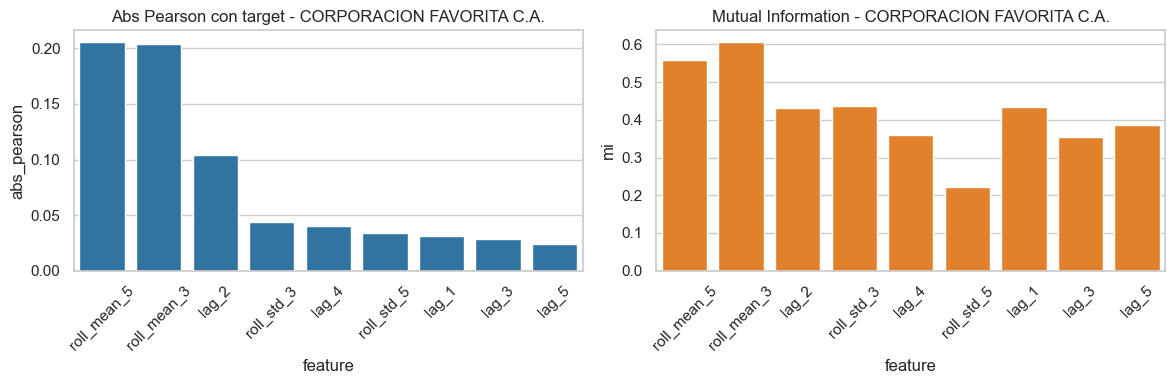

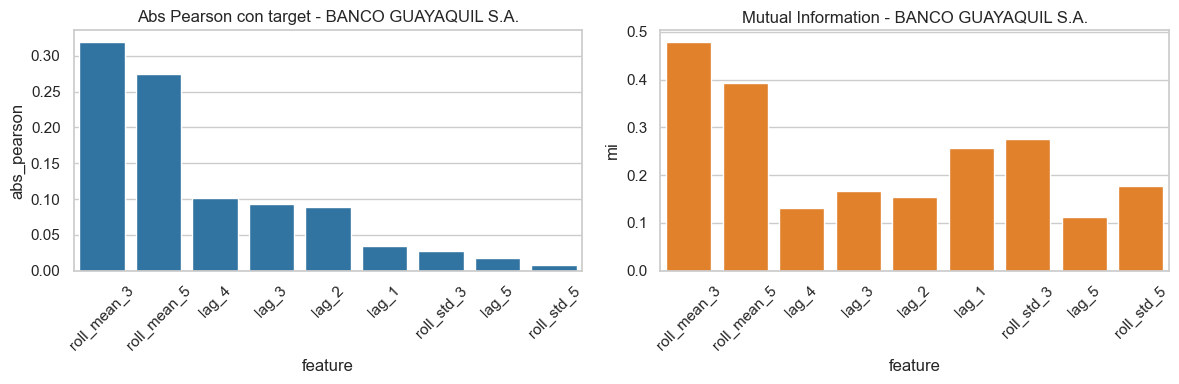

In [6]:
# Visualizacion compacta de relevancia
for empresa in empresas_objetivo:
    c = corr_df[corr_df['empresa'] == empresa].copy().set_index('feature')
    m = mi_df[mi_df['empresa'] == empresa].copy().set_index('feature')

    merged = c.join(m[['mi']])
    merged = merged.sort_values('abs_pearson', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.barplot(x=merged.index, y=merged['abs_pearson'], ax=axes[0], color='tab:blue')
    axes[0].set_title('Abs Pearson con target - {}'.format(empresa))
    axes[0].tick_params(axis='x', rotation=45)

    sns.barplot(x=merged.index, y=merged['mi'], ax=axes[1], color='tab:orange')
    axes[1].set_title('Mutual Information - {}'.format(empresa))
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

## 5. Respuestas criticas obligatorias
Se responde explicitamente si lag_1 domina y si las demas features aportan.

In [7]:
print('=== RESPUESTAS CRITICAS DE FEATURE ENGINEERING ===')

for empresa in empresas_objetivo:
    c = corr_df[corr_df['empresa'] == empresa].copy()
    m = mi_df[mi_df['empresa'] == empresa].copy()

top_corr = c.sort_values('abs_pearson', ascending=False).iloc[0]
top_mi = m.sort_values('mi', ascending=False).iloc[0]

lag1_corr = c[c['feature'] == 'lag_1']['abs_pearson'].values[0]
max_corr = c['abs_pearson'].max()
domina_lag1_corr = np.isclose(lag1_corr, max_corr) or lag1_corr >= (0.9 * max_corr)

lag1_mi = m[m['feature'] == 'lag_1']['mi'].values[0]
max_mi = m['mi'].max()
domina_lag1_mi = np.isclose(lag1_mi, max_mi) or lag1_mi >= (0.9 * max_mi)

otras_corr = c[c['feature'] != 'lag_1']['abs_pearson'].max()
otras_mi = m[m['feature'] != 'lag_1']['mi'].max()

print('')
print('Empresa: {}'.format(empresa))
print('- Top correlacion absoluta: {} ({:.4f})'.format(top_corr['feature'], top_corr['abs_pearson']))
print('- Top MI preliminar: {} ({:.6f})'.format(top_mi['feature'], top_mi['mi']))
print('- lag_1 domina por correlacion?: {}'.format('SI' if domina_lag1_corr else 'NO'))
print('- lag_1 domina por MI?: {}'.format('SI' if domina_lag1_mi else 'NO'))
print('- Mejor feature alternativa (corr abs): {:.4f}'.format(otras_corr))
print('- Mejor feature alternativa (MI): {:.6f}'.format(otras_mi))

print('Conclusion operativa:')
if domina_lag1_corr or domina_lag1_mi:
    print('- lag_1 es feature central y debe permanecer como base del set minimo.')
else:
    print('- lag_1 no domina de forma clara; mantener set minimo para contraste en fase de modelado.')

if (otras_corr > 0.03) or (otras_mi > 0.001):
    print('- Otras features muestran aporte marginal detectable; mantener lag_2-lag_5 y rolling cortas.')
else:
    print('- Aporte de features adicionales es bajo; priorizar parsimonia en Fase 5.')

=== RESPUESTAS CRITICAS DE FEATURE ENGINEERING ===

Empresa: BANCO GUAYAQUIL S.A.
- Top correlacion absoluta: roll_mean_3 (0.3195)
- Top MI preliminar: roll_mean_3 (0.478986)
- lag_1 domina por correlacion?: NO
- lag_1 domina por MI?: NO
- Mejor feature alternativa (corr abs): 0.3195
- Mejor feature alternativa (MI): 0.478986
Conclusion operativa:
- lag_1 no domina de forma clara; mantener set minimo para contraste en fase de modelado.
- Otras features muestran aporte marginal detectable; mantener lag_2-lag_5 y rolling cortas.


In [8]:
# Resumen numerico compacto para conclusiones de fase
print('=== OUTLIERS / HEAVY TAILS ===')
print(outlier_df.to_string(index=False))

print('\n=== TOP 3 POR CORR ABS (empresa) ===')
for empresa in empresas_objetivo:
    t = corr_df[corr_df['empresa'] == empresa].sort_values('abs_pearson', ascending=False).head(3)
    print(f'\n{empresa}')
    print(t[['feature', 'pearson', 'spearman', 'abs_pearson']].to_string(index=False))

print('\n=== TOP 3 POR MI (empresa) ===')
for empresa in empresas_objetivo:
    t = mi_df[mi_df['empresa'] == empresa].sort_values('mi', ascending=False).head(3)
    print(f'\n{empresa}')
    print(t[['feature', 'mi']].to_string(index=False))

print('\n=== LAG_1 VS ALTERNATIVAS ===')
for empresa in empresas_objetivo:
    c = corr_df[corr_df['empresa'] == empresa]
    m = mi_df[mi_df['empresa'] == empresa]
    lag1_corr = float(c[c['feature'] == 'lag_1']['abs_pearson'].iloc[0])
    best_corr = float(c['abs_pearson'].max())
    lag1_mi = float(m[m['feature'] == 'lag_1']['mi'].iloc[0])
    best_mi = float(m['mi'].max())
    print(f'- {empresa}: lag1_corr={lag1_corr:.6f}, best_corr={best_corr:.6f}, lag1_mi={lag1_mi:.6f}, best_mi={best_mi:.6f}')

print('\n=== MUESTRA FINAL PARA FEATURES ===')
print(df_model_base.groupby('empresa').size().rename('n_filas_model_base').to_string())

=== OUTLIERS / HEAVY TAILS ===
                  empresa  q01_ret  q99_ret  pct_extremos_1pct  kurtosis_ret
CORPORACION FAVORITA C.A. -0.03856 0.043649           2.019002     30.342524
     BANCO GUAYAQUIL S.A. -0.09531 0.098084           2.001741     16.558910

=== TOP 3 POR CORR ABS (empresa) ===

CORPORACION FAVORITA C.A.
    feature   pearson  spearman  abs_pearson
roll_mean_5 -0.205835 -0.159353     0.205835
roll_mean_3 -0.203590 -0.175650     0.203590
      lag_2  0.103806  0.072967     0.103806

BANCO GUAYAQUIL S.A.
    feature   pearson  spearman  abs_pearson
roll_mean_3 -0.319510 -0.232509     0.319510
roll_mean_5 -0.274380 -0.169138     0.274380
      lag_4  0.100875  0.113839     0.100875

=== TOP 3 POR MI (empresa) ===

CORPORACION FAVORITA C.A.
    feature       mi
roll_mean_3 0.606598
roll_mean_5 0.558255
 roll_std_3 0.437871

BANCO GUAYAQUIL S.A.
    feature       mi
roll_mean_3 0.478986
roll_mean_5 0.391876
 roll_std_3 0.275588

=== LAG_1 VS ALTERNATIVAS ===
- CORPORACI

## 6. Conclusiones de fase (basadas en resultados obtenidos)

1. Errores criticos
- No se detectaron errores de construccion en el set minimo de features.
- El dataset final para analisis de features quedo en:
  - `CORPORACION FAVORITA C.A.`: `1684` filas
  - `BANCO GUAYAQUIL S.A.`: `1149` filas

2. Riesgos metodologicos
- Persisten heavy tails relevantes en retornos (kurtosis alta):
  - Favorita: `30.3425`
  - Banco Guayaquil: `16.5589`
- Existe heterocedasticidad, por lo que el escalado robusto es preferible para evitar dominancia de extremos.
- Diferencia de tamano muestral entre emisores puede sesgar comparaciones directas de importancia.

3. Interpretacion de evidencia por feature
- **lag_1 no domina** en esta configuracion de target (`t+1`).
  - Favorita: `|corr(lag_1,target)| = 0.0316` vs mejor feature `roll_mean_5 = 0.2058`
  - Banco: `|corr(lag_1,target)| = 0.0345` vs mejor feature `roll_mean_3 = 0.3195`
- Importancia preliminar (Mutual Information) tambien favorece features rolling:
  - Favorita: top MI `roll_mean_3 = 0.6066`, `roll_mean_5 = 0.5583`, `roll_std_3 = 0.4379`, `lag_1 = 0.4347`
  - Banco: top MI `roll_mean_3 = 0.4790`, `roll_mean_5 = 0.3919`, `roll_std_3 = 0.2756`, `lag_1 = 0.2561`
- Conclusión: las features de corto plazo rolling capturan mejor senal local que `lag_1` aislado en esta formulacion.

4. Decision de fase
- Continuar a Fase 5 con set parsimonioso guiado por evidencia.
- Set recomendado inicial:
  - `lag_1`, `lag_2` (control de memoria corta)
  - `roll_mean_3`, `roll_mean_5` (senal dominante)
  - `roll_std_3` (regimen de volatilidad)
- `lag_3`, `lag_4`, `lag_5`, `roll_std_5` quedan como candidatos secundarios para contraste de robustez.

5. Proximo paso exacto
- Ejecutar SVR con walk-forward usando este set minimo y comparar kernels (`linear`, `rbf`, `poly`) sin fuga temporal.
- Reportar si incluir/excluir features secundarias cambia MAE/MSE/R2 de forma consistente por emisor.